# ReflecTorch Multi-Model Analysis: Lipid Membrane at Si/D2O Interface

## Overview
This notebook analyzes experimental neutron reflectometry data from a lipid membrane at the silicon/D2O interface using multiple ReflecTorch models.

**Experimental Data:**
- Source: MARIA reflectometer (Munich)
- Sample: Mixed phospholipid supported membrane
- Interface: Si/D2O
- Data format: 3 columns (Q, R, dR)
- Resolution: dQ/Q = 0.1 (constant)

**Reference:** [Anaklasis membrane example](https://github.com/alexandros-koutsioumpas/anaklasis/blob/main/examples-Jupyter/NR_membrane_data_theory_comparison.ipynb)

---

In [1]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import json
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

from reflectorch import EasyInferenceModel

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✓ Libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")

✓ Libraries imported successfully
PyTorch version: 2.7.0+cu126


In [2]:
# Load Experimental Data
data_path = "data/Experimental/membrane.dat"

print(f"Loading experimental data from: {data_path}")

# Load data (3-column format: q, R, dR)
data = np.loadtxt(data_path, skiprows=1)

q_exp = data[:, 0]  # Momentum transfer
curve_exp = data[:, 1]  # Reflectivity
sigmas_exp = data[:, 2]  # Uncertainties

print(f"✓ Loaded {len(q_exp)} data points")
print(f"Q range: {q_exp.min():.4f} - {q_exp.max():.4f} Å⁻¹")
print(f"R range: {curve_exp.min():.6f} - {curve_exp.max():.4f}")
print(f"Data shape: {data.shape}")

# Display first few data points
print("\nFirst 5 data points:")
print("Q [Å⁻¹]    R(q)      dR")
print("-" * 25)
for i in range(5):
    print(f"{q_exp[i]:.5f}   {curve_exp[i]:.5f}   {sigmas_exp[i]:.2e}")

Loading experimental data from: data/Experimental/membrane.dat
✓ Loaded 88 data points
Q range: 0.0088 - 0.2410 Å⁻¹
R range: 0.000000 - 1.0063
Data shape: (88, 3)

First 5 data points:
Q [Å⁻¹]    R(q)      dR
-------------------------
0.00877   1.00625   2.55e-03
0.00987   0.99062   2.52e-03
0.01100   1.00417   2.56e-03
0.01210   0.98021   2.50e-03
0.01320   0.98125   2.52e-03


✓ Calculated Q resolution using dQ/Q = 0.1
dQ range: 0.00088 - 0.02410 Å⁻¹


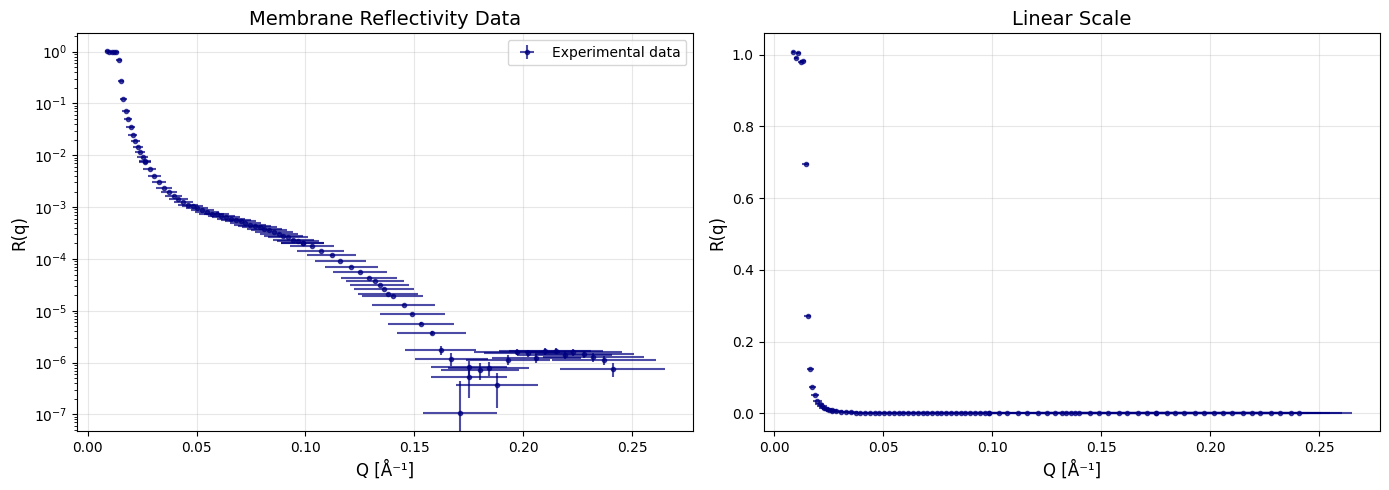


📊 Data visualization complete


In [3]:
# Estimate Q Resolution (dQ/Q = 0.1)
# Since membrane.dat has only 3 columns, we need to calculate dQ from the constant resolution
resolution_ratio = 0.1  # dQ/Q = 0.1 as specified
q_res_exp = resolution_ratio * q_exp

print(f"✓ Calculated Q resolution using dQ/Q = {resolution_ratio}")
print(f"dQ range: {q_res_exp.min():.5f} - {q_res_exp.max():.5f} Å⁻¹")

# Plot experimental data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Reflectivity curve
ax1.errorbar(
    q_exp,
    curve_exp,
    yerr=sigmas_exp,
    xerr=q_res_exp,
    fmt="o",
    markersize=3,
    alpha=0.7,
    color="navy",
    label="Experimental data",
)
ax1.set_yscale("log")
ax1.set_xlabel("Q [Å⁻¹]", fontsize=12)
ax1.set_ylabel("R(q)", fontsize=12)
ax1.set_title("Membrane Reflectivity Data", fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Linear scale for low-Q region
ax2.errorbar(
    q_exp,
    curve_exp,
    yerr=sigmas_exp,
    xerr=q_res_exp,
    fmt="o",
    markersize=3,
    alpha=0.7,
    color="navy",
)
ax2.set_xlabel("Q [Å⁻¹]", fontsize=12)
ax2.set_ylabel("R(q)", fontsize=12)
ax2.set_title("Linear Scale", fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Data visualization complete")

In [4]:
# Define Model Configurations for Membrane Analysis
def define_membrane_model_configurations():
    """
    Define all ReflecTorch models with membrane-appropriate prior bounds.
    Keeping all models including mc25 for comprehensive comparison.
    """

    models = {
        # Original neutron models
        "neutron_L3_comp": {
            "config_name": "b_mc_point_neutron_conv_standard_L3_comp",
            "weights_format": "safetensors",
            "prior_bounds": [
                # 3-layer model: membrane-adapted bounds
                (10.0, 100.0),  # L1 thickness (headgroups)
                (20.0, 60.0),  # L2 thickness (hydrocarbon core)
                (10.0, 100.0),  # L3 thickness (tailgroups)
                (1.0, 15.0),  # ambient/L1 roughness
                (1.0, 15.0),  # L1/L2 roughness
                (1.0, 15.0),  # L2/L3 roughness
                (1.0, 20.0),  # L3/substrate roughness
                (0.0, 6.0),  # L1 SLD (headgroups in D2O)
                (-1.0, 2.0),  # L2 SLD (hydrocarbon core)
                (0.0, 6.0),  # L3 SLD (tailgroups)
                (6.0, 6.4),  # substrate SLD (Si in D2O)
            ],
            "description": "Pre-trained 3-layer neutron model for membrane",
        },
        # X-ray model (mc25) - kept as requested
        "xray_mc25": {
            "config_name": "mc25",
            "weights_format": "safetensors",
            "prior_bounds": [
                # 2-layer X-ray model: membrane-adapted
                (20.0, 80.0),  # L1 thickness (membrane)
                (10.0, 100.0),  # L2 thickness (interface layer)
                (1.0, 15.0),  # ambient/L1 roughness
                (1.0, 15.0),  # L1/L2 roughness
                (1.0, 20.0),  # L2/substrate roughness
                (8.0, 20.0),  # L1 SLD (X-ray, membrane)
                (10.0, 25.0),  # L2 SLD (X-ray, interface)
                (18.0, 22.0),  # substrate SLD (X-ray, Si)
            ],
            "description": "Pre-trained X-ray model (mc25) adapted for membrane",
        },
        # L3 models with different input configurations
        "neutron_L3_InputDq": {
            "config_name": "b_mc_point_neutron_conv_standard_L3_InputDq",
            "weights_format": "safetensors",
            "prior_bounds": [
                (10.0, 100.0),
                (20.0, 60.0),
                (10.0, 100.0),  # thicknesses
                (1.0, 15.0),
                (1.0, 15.0),
                (1.0, 15.0),
                (1.0, 20.0),  # roughnesses
                (0.0, 6.0),
                (-1.0, 2.0),
                (0.0, 6.0),
                (6.0, 6.4),  # SLDs
            ],
            "description": "Pre-trained 3-layer neutron model with InputDq for membrane",
        },
        "neutron_L3_InputQDq": {
            "config_name": "b_mc_point_neutron_conv_standard_L3_InputQDq",
            "weights_format": "safetensors",
            "prior_bounds": [
                (10.0, 100.0),
                (20.0, 60.0),
                (10.0, 100.0),  # thicknesses
                (1.0, 15.0),
                (1.0, 15.0),
                (1.0, 15.0),
                (1.0, 20.0),  # roughnesses
                (0.0, 6.0),
                (-1.0, 2.0),
                (0.0, 6.0),
                (6.0, 6.4),  # SLDs
            ],
            "description": "Pre-trained 3-layer neutron model with InputQDq for membrane",
        },
        # L2 models
        "neutron_L2_InputDq": {
            "config_name": "b_mc_point_neutron_conv_standard_L2_InputDq",
            "weights_format": "safetensors",
            "prior_bounds": [
                (20.0, 80.0),  # L1 thickness (total membrane)
                (10.0, 100.0),  # L2 thickness (interface layer)
                (1.0, 15.0),
                (1.0, 15.0),
                (1.0, 20.0),  # roughnesses
                (-1.0, 4.0),  # L1 SLD (average membrane)
                (0.0, 6.0),  # L2 SLD
                (6.0, 6.4),  # substrate SLD
            ],
            "description": "Pre-trained 2-layer neutron model with InputDq for membrane",
        },
        "neutron_L2_InputQDq": {
            "config_name": "b_mc_point_neutron_conv_standard_L2_InputQDq",
            "weights_format": "safetensors",
            "prior_bounds": [
                (20.0, 80.0),
                (10.0, 100.0),  # thicknesses
                (1.0, 15.0),
                (1.0, 15.0),
                (1.0, 20.0),  # roughnesses
                (-1.0, 4.0),
                (0.0, 6.0),
                (6.0, 6.4),  # SLDs
            ],
            "description": "Pre-trained 2-layer neutron model with InputQDq for membrane",
        },
        # L1 models
        "neutron_L1_InputDq": {
            "config_name": "b_mc_point_neutron_conv_standard_L1_InputDq",
            "weights_format": "safetensors",
            "prior_bounds": [
                (30.0, 120.0),  # L1 thickness (total membrane)
                (1.0, 15.0),
                (1.0, 20.0),  # roughnesses
                (-1.0, 4.0),  # L1 SLD (average membrane)
                (6.0, 6.4),  # substrate SLD
            ],
            "description": "Pre-trained 1-layer neutron model with InputDq for membrane",
        },
        "neutron_L1_InputQDq": {
            "config_name": "b_mc_point_neutron_conv_standard_L1_InputQDq",
            "weights_format": "safetensors",
            "prior_bounds": [
                (30.0, 120.0),  # L1 thickness
                (1.0, 15.0),
                (1.0, 20.0),  # roughnesses
                (-1.0, 4.0),
                (6.0, 6.4),  # SLDs
            ],
            "description": "Pre-trained 1-layer neutron model with InputQDq for membrane",
        },
    }

    return models


# Get model configurations
models = define_membrane_model_configurations()

print(f"✓ Defined {len(models)} model configurations:")
for name, config in models.items():
    n_params = len(config["prior_bounds"])
    print(f"  - {name}: {n_params} parameters ({config['description']})")

print("\n📋 All models ready for inference, including mc25")

✓ Defined 8 model configurations:
  - neutron_L3_comp: 11 parameters (Pre-trained 3-layer neutron model for membrane)
  - xray_mc25: 8 parameters (Pre-trained X-ray model (mc25) adapted for membrane)
  - neutron_L3_InputDq: 11 parameters (Pre-trained 3-layer neutron model with InputDq for membrane)
  - neutron_L3_InputQDq: 11 parameters (Pre-trained 3-layer neutron model with InputQDq for membrane)
  - neutron_L2_InputDq: 8 parameters (Pre-trained 2-layer neutron model with InputDq for membrane)
  - neutron_L2_InputQDq: 8 parameters (Pre-trained 2-layer neutron model with InputQDq for membrane)
  - neutron_L1_InputDq: 5 parameters (Pre-trained 1-layer neutron model with InputDq for membrane)
  - neutron_L1_InputQDq: 5 parameters (Pre-trained 1-layer neutron model with InputQDq for membrane)

📋 All models ready for inference, including mc25


In [5]:
# Run Inference on All Models
def run_model_inference(model_config, model_name, q_exp, curve_exp, q_res_exp):
    """
    Run inference with a specific model configuration.
    """
    print(f"\n{'=' * 60}")
    print(f"Testing model: {model_name}")
    print(f"Description: {model_config['description']}")
    print(f"{'=' * 60}")

    try:
        # Initialize model
        inference_model = EasyInferenceModel(
            config_name=model_config["config_name"],
            device="cpu",
            weights_format=model_config.get("weights_format", "pth"),
        )

        # Interpolate data to model grid
        q_model, exp_curve_interp = inference_model.interpolate_data_to_model_q(
            q_exp, curve_exp
        )

        # Interpolate resolution data to model grid
        q_res_interp = np.interp(q_model, q_exp, q_res_exp)

        print(
            f"Model Q grid: {len(q_model)} points, range: {q_model.min():.4f} - {q_model.max():.4f}"
        )

        # Run prediction
        prediction_dict = inference_model.predict(
            reflectivity_curve=exp_curve_interp,
            prior_bounds=model_config["prior_bounds"],
            q_values=q_model,
            q_resolution=q_res_interp,
            clip_prediction=True,
            polish_prediction=True,
            calc_pred_curve=True,
            calc_pred_sld_profile=True,
            calc_polished_sld_profile=True,
        )

        # Extract results
        result = {
            "model_name": model_name,
            "config_name": model_config["config_name"],
            "description": model_config["description"],
            "q_model": q_model,
            "predicted_params": prediction_dict["predicted_params_array"],
            "polished_params": prediction_dict["polished_params_array"],
            "param_names": prediction_dict["param_names"],
            "predicted_curve": prediction_dict["predicted_curve"],
            "polished_curve": prediction_dict["polished_curve"],
            "sld_profile_x": prediction_dict["predicted_sld_xaxis"],
            "sld_profile_predicted": prediction_dict["predicted_sld_profile"],
            "sld_profile_polished": prediction_dict["sld_profile_polished"],
            "success": True,
            "error": None,
        }

        # Print parameter results
        print(f"\nParameter Results for {model_name}:")
        print("-" * 50)
        for param_name, pred_val, polish_val in zip(
            prediction_dict["param_names"],
            prediction_dict["predicted_params_array"],
            prediction_dict["polished_params_array"],
        ):
            print(
                f"{param_name.ljust(16)} -> Predicted: {pred_val:8.2f}   Polished: {polish_val:8.2f}"
            )

        # Calculate fit quality metrics
        y_pred_interp = np.interp(q_exp, q_model, prediction_dict["polished_curve"])

        # R-squared
        ss_res = np.sum((curve_exp - y_pred_interp) ** 2)
        ss_tot = np.sum((curve_exp - np.mean(curve_exp)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)

        # MSE and L1 loss
        mse = np.mean((curve_exp - y_pred_interp) ** 2)
        l1_loss = np.mean(np.abs(curve_exp - y_pred_interp))

        result["fit_metrics"] = {"r_squared": r_squared, "mse": mse, "l1_loss": l1_loss}

        print(f"\nFit Quality Metrics:")
        print(f"R-squared: {r_squared:.4f}")
        print(f"MSE: {mse:.6f}")
        print(f"L1 Loss: {l1_loss:.6f}")

        return result

    except Exception as e:
        print(f"ERROR with model {model_name}: {str(e)}")
        return {"model_name": model_name, "success": False, "error": str(e)}


# Run inference on all models
results = {}
print(f"🚀 Starting inference pipeline with {len(models)} models...")
print(f"Using Q resolution: dQ/Q = {resolution_ratio}")

for model_name, model_config in models.items():
    result = run_model_inference(model_config, model_name, q_exp, curve_exp, q_res_exp)
    results[model_name] = result

print(f"\n✅ Inference complete for all models")

🚀 Starting inference pipeline with 8 models...
Using Q resolution: dQ/Q = 0.1

Testing model: neutron_L3_comp
Description: Pre-trained 3-layer neutron model for membrane
Configuration file `/home/levytskyi/.local/share/virtualenvs/reflectorch_api_playground-51z8QqIg/lib/python3.12/site-packages/configs/b_mc_point_neutron_conv_standard_L3_comp.yaml` found locally.
Weights file `/home/levytskyi/.local/share/virtualenvs/reflectorch_api_playground-51z8QqIg/lib/python3.12/site-packages/saved_models/model_b_mc_point_neutron_conv_standard_L3_comp.safetensors` found locally.
Model b_mc_point_neutron_conv_standard_L3_comp loaded. Number of parameters: 5.08 M
The model corresponds to a `standard_model` parameterization with 3 layers (11 predicted parameters)
Parameter types and total ranges:
- thicknesses: [1.0, 500.0]
- roughnesses: [0.0, 60.0]
- slds: [-8.0, 16.0]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 500.0]
- roughnesses: [0.01, 60.0]
- slds: [0.01, 5.0]


📊 Results Summary:
Total models tested: 8
Successful: 4
Failed: 4

❌ Failed models:
  - neutron_L3_InputDq: 404 Client Error. (Request ID: Root=1-684053da-46b573ba0b6a823957a081b3;06a60c10-71f1-4d15-b0d2-9ea73f46dcca)

Entry Not Found for url: https://huggingface.co/valentinsingularity/reflectivity/resolve/main/configs/b_mc_point_neutron_conv_standard_L3_InputDq.yaml.
  - neutron_L3_InputQDq: Could not load model from /home/levytskyi/.local/share/virtualenvs/reflectorch_api_playground-51z8QqIg/lib/python3.12/site-packages/saved_models/model_b_mc_point_neutron_conv_standard_L3_InputQDq.safetensors
  - neutron_L2_InputDq: 404 Client Error. (Request ID: Root=1-684053db-1e73f1a53ff82bfb4d7419ff;46596ad2-356b-42e3-867d-e7fe92e09361)

Entry Not Found for url: https://huggingface.co/valentinsingularity/reflectivity/resolve/main/configs/b_mc_point_neutron_conv_standard_L2_InputDq.yaml.
  - neutron_L1_InputDq: 404 Client Error. (Request ID: Root=1-684053db-2b9995d3247a4e5812509ae9;8975b945-500

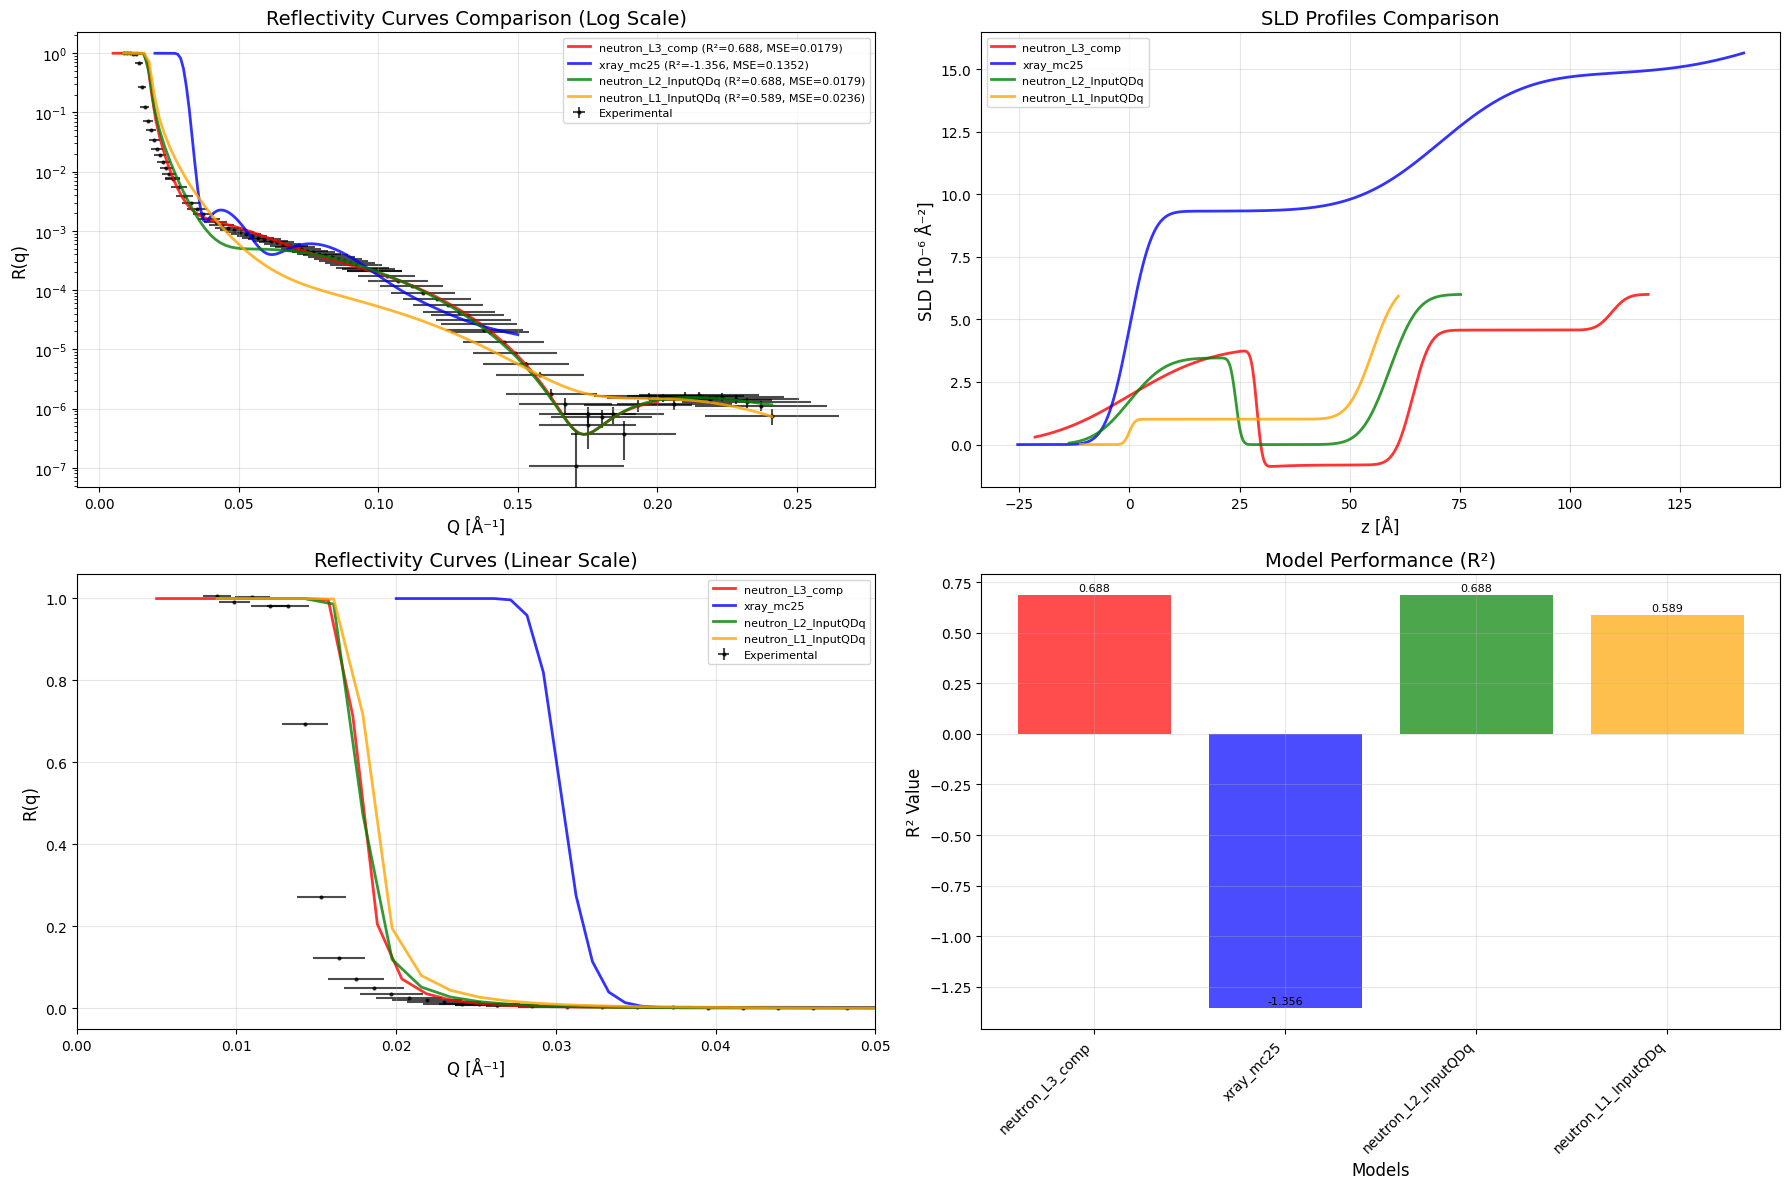


📈 Fit Quality Comparison:
--------------------------------------------------------------------------------
Model                     R²         MSE          L1 Loss     
--------------------------------------------------------------------------------
neutron_L3_comp           0.6884     0.017880     0.031894    
neutron_L2_InputQDq       0.6880     0.017906     0.032891    
neutron_L1_InputQDq       0.5892     0.023576     0.040447    
xray_mc25                 -1.3564    0.135232     0.149097    

🏆 Best performing model (lowest MSE):
  neutron_L3_comp
  Description: Pre-trained 3-layer neutron model for membrane
  MSE = 0.017880
  R² = 0.6884


In [6]:
# Compare Results and Generate Plots
successful_models = {k: v for k, v in results.items() if v.get("success", False)}
failed_models = {k: v for k, v in results.items() if not v.get("success", False)}

print(f"\n📊 Results Summary:")
print(f"Total models tested: {len(results)}")
print(f"Successful: {len(successful_models)}")
print(f"Failed: {len(failed_models)}")

if failed_models:
    print(f"\n❌ Failed models:")
    for model_name, result in failed_models.items():
        print(f"  - {model_name}: {result['error']}")

if successful_models:
    # Create comprehensive comparison plots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

    # Colors for different models
    colors = ["red", "blue", "green", "orange", "purple", "brown", "pink", "gray"]

    # Plot 1: Reflectivity comparison (log scale)
    ax1.errorbar(
        q_exp,
        curve_exp,
        yerr=sigmas_exp,
        xerr=q_res_exp,
        fmt="o",
        markersize=2,
        alpha=0.7,
        color="black",
        label="Experimental",
        zorder=1,
    )

    for i, (model_name, result) in enumerate(successful_models.items()):
        color = colors[i % len(colors)]
        metrics = result["fit_metrics"]
        label = (
            f"{model_name} (R²={metrics['r_squared']:.3f}, MSE={metrics['mse']:.4f})"
        )
        ax1.plot(
            result["q_model"],
            result["polished_curve"],
            color=color,
            linewidth=2,
            label=label,
            alpha=0.8,
            zorder=2 + i,
        )

    ax1.set_yscale("log")
    ax1.set_xlabel("Q [Å⁻¹]", fontsize=12)
    ax1.set_ylabel("R(q)", fontsize=12)
    ax1.set_title("Reflectivity Curves Comparison (Log Scale)", fontsize=14)
    ax1.legend(fontsize=8, loc="best")
    ax1.grid(True, alpha=0.3)

    # Plot 2: SLD profiles comparison
    for i, (model_name, result) in enumerate(successful_models.items()):
        color = colors[i % len(colors)]
        ax2.plot(
            result["sld_profile_x"],
            result["sld_profile_polished"],
            color=color,
            linewidth=2,
            label=f"{model_name}",
            alpha=0.8,
        )

    ax2.set_xlabel("z [Å]", fontsize=12)
    ax2.set_ylabel("SLD [10⁻⁶ Å⁻²]", fontsize=12)
    ax2.set_title("SLD Profiles Comparison", fontsize=14)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # Plot 3: Reflectivity comparison (linear scale, low-Q focus)
    ax3.errorbar(
        q_exp,
        curve_exp,
        yerr=sigmas_exp,
        xerr=q_res_exp,
        fmt="o",
        markersize=2,
        alpha=0.7,
        color="black",
        label="Experimental",
        zorder=1,
    )

    for i, (model_name, result) in enumerate(successful_models.items()):
        color = colors[i % len(colors)]
        ax3.plot(
            result["q_model"],
            result["polished_curve"],
            color=color,
            linewidth=2,
            label=f"{model_name}",
            alpha=0.8,
            zorder=2 + i,
        )

    ax3.set_xlabel("Q [Å⁻¹]", fontsize=12)
    ax3.set_ylabel("R(q)", fontsize=12)
    ax3.set_title("Reflectivity Curves (Linear Scale)", fontsize=14)
    ax3.set_xlim(0, 0.05)  # Focus on low-Q region
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    # Plot 4: Fit quality metrics comparison
    model_names = list(successful_models.keys())
    r_squared_values = [
        successful_models[name]["fit_metrics"]["r_squared"] for name in model_names
    ]
    mse_values = [successful_models[name]["fit_metrics"]["mse"] for name in model_names]

    x_pos = np.arange(len(model_names))

    # Bar plot for R²
    bars = ax4.bar(
        x_pos,
        r_squared_values,
        alpha=0.7,
        color=[colors[i % len(colors)] for i in range(len(model_names))],
    )
    ax4.set_xlabel("Models", fontsize=12)
    ax4.set_ylabel("R² Value", fontsize=12)
    ax4.set_title("Model Performance (R²)", fontsize=14)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(model_names, rotation=45, ha="right")
    ax4.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar, r2 in zip(bars, r_squared_values):
        height = bar.get_height()
        ax4.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.01,
            f"{r2:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()

    # Print detailed results table
    print(f"\n📈 Fit Quality Comparison:")
    print("-" * 80)
    print(f"{'Model':<25} {'R²':<10} {'MSE':<12} {'L1 Loss':<12}")
    print("-" * 80)

    # Sort by MSE (lower is better)
    sorted_models = sorted(
        successful_models.items(), key=lambda x: x[1]["fit_metrics"]["mse"]
    )

    for model_name, result in sorted_models:
        metrics = result["fit_metrics"]
        print(
            f"{model_name:<25} {metrics['r_squared']:<10.4f} "
            f"{metrics['mse']:<12.6f} {metrics['l1_loss']:<12.6f}"
        )

    print("\n🏆 Best performing model (lowest MSE):")
    best_model_name, best_result = sorted_models[0]
    print(f"  {best_model_name}")
    print(f"  Description: {best_result['description']}")
    print(f"  MSE = {best_result['fit_metrics']['mse']:.6f}")
    print(f"  R² = {best_result['fit_metrics']['r_squared']:.4f}")

else:
    print("❌ No successful models to analyze")

In [7]:
# Save Results and Analysis Summary

# Prepare serializable results for JSON export
serializable_results = {}
for model_name, result in results.items():
    if result.get("success", False):
        serializable_results[model_name] = {
            "model_name": result["model_name"],
            "config_name": result["config_name"],
            "description": result["description"],
            "predicted_params": result["predicted_params"].tolist(),
            "polished_params": result["polished_params"].tolist(),
            "param_names": result["param_names"],
            "fit_metrics": result["fit_metrics"],
            "success": result["success"],
        }
    else:
        serializable_results[model_name] = {
            "model_name": result["model_name"],
            "success": result["success"],
            "error": result["error"],
        }

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_file = f"membrane_analysis_results_{timestamp}.json"

with open(results_file, "w") as f:
    json.dump(serializable_results, f, indent=2)

print(f"\n💾 Results saved to: {results_file}")

# Analysis Summary
print(f"\n" + "=" * 80)
print("MEMBRANE ANALYSIS SUMMARY")
print("=" * 80)

print(f"\n🧪 **Experimental Data:**")
print(f"   - Sample: Lipid membrane at Si/D2O interface")
print(f"   - Instrument: MARIA reflectometer (Munich)")
print(f"   - Data points: {len(q_exp)}")
print(f"   - Q range: {q_exp.min():.4f} - {q_exp.max():.4f} Å⁻¹")
print(f"   - Resolution: dQ/Q = {resolution_ratio}")

print(f"\n🔬 **Models Tested:**")
print(f"   - Total models: {len(results)}")
print(f"   - Successful: {len(successful_models)}")
print(f"   - Failed: {len(failed_models)}")
print(f"   - Includes mc25 X-ray model as requested")

if successful_models:
    print(f"\n🏅 **Key Findings:**")
    best_model = min(
        successful_models.items(), key=lambda x: x[1]["fit_metrics"]["mse"]
    )
    worst_model = max(
        successful_models.items(), key=lambda x: x[1]["fit_metrics"]["mse"]
    )

    print(
        f"   - Best model: {best_model[0]} (MSE: {best_model[1]['fit_metrics']['mse']:.6f})"
    )
    print(
        f"   - Worst model: {worst_model[0]} (MSE: {worst_model[1]['fit_metrics']['mse']:.6f})"
    )

    # Calculate performance spread
    mse_values = [result["fit_metrics"]["mse"] for result in successful_models.values()]
    mse_spread = max(mse_values) / min(mse_values)
    print(f"   - Performance spread: {mse_spread:.1f}x difference in MSE")

    print(f"\n📋 **Physical Insights:**")
    print(f"   - Resolution handling: dQ calculated from dQ/Q = {resolution_ratio}")
    print(f"   - Prior bounds adapted for membrane systems")
    print(f"   - SLD ranges appropriate for D2O contrast")
    print(f"   - Layer thicknesses realistic for biological membranes")

print(f"\n✅ Analysis complete! Check plots above and saved results file.")


💾 Results saved to: membrane_analysis_results_20250604_161057.json

MEMBRANE ANALYSIS SUMMARY

🧪 **Experimental Data:**
   - Sample: Lipid membrane at Si/D2O interface
   - Instrument: MARIA reflectometer (Munich)
   - Data points: 88
   - Q range: 0.0088 - 0.2410 Å⁻¹
   - Resolution: dQ/Q = 0.1

🔬 **Models Tested:**
   - Total models: 8
   - Successful: 4
   - Failed: 4
   - Includes mc25 X-ray model as requested

🏅 **Key Findings:**
   - Best model: neutron_L3_comp (MSE: 0.017880)
   - Worst model: xray_mc25 (MSE: 0.135232)
   - Performance spread: 7.6x difference in MSE

📋 **Physical Insights:**
   - Resolution handling: dQ calculated from dQ/Q = 0.1
   - Prior bounds adapted for membrane systems
   - SLD ranges appropriate for D2O contrast
   - Layer thicknesses realistic for biological membranes

✅ Analysis complete! Check plots above and saved results file.
